### Cell 1 — Backtest Utilities (returns, equity, drawdown, metrics, trade logger)

- **Mục tiêu:** Chuẩn bị các hàm/tầng tiện ích dùng lại cho mọi chiến lược (không dính dữ liệu cụ thể).
- **Thành phần chính:**
  - `calc_returns(df)`: tính **daily return** từ `close`.
  - `equity_from_position(returns, position)`: dựng **equity curve** với **position của ngày hôm qua** → *no lookahead*.
  - `compute_drawdown(equity)`: tính **đỉnh chạy**, **drawdown**, **maxDD**.
  - `perf_summary(returns)`: tóm tắt **CAGR**, **Vol_Ann**, **Sharpe**, **MaxDD**, **EquityEnd**, **Ndays**.
  - `TradeLogger`: logger giao dịch tối giản (timestamp, action, price, size/weight, equity_after) → xuất DataFrame.
- **Vai trò:** Là “xương sống” cho phần backtest; các cell sau chỉ cần gọi lại để chạy chiến lược, log trade và in báo cáo.


In [1]:
# CELL 1 — Backtest utilities: returns, equity, drawdowns, metrics, trade logger
import pandas as pd
import numpy as np
from dataclasses import dataclass, field

# ========= Returns & Equity =========
def calc_returns(df: pd.DataFrame, price_col="close") -> pd.Series:
    """Simple returns r_t = P_t/P_{t-1} - 1"""
    r = df[price_col].pct_change()
    return r.fillna(0.0)

def equity_from_position(returns: pd.Series, position: pd.Series, initial_equity: float = 1.0) -> pd.Series:
    """
    Vectorized equity curve with daily revaluation.
    Uses yesterday's position for today's return (no lookahead).
    """
    pos_shifted = position.shift(1).fillna(0.0)
    pnl = pos_shifted * returns
    equity = (1.0 + pnl).cumprod() * initial_equity
    return equity

# ========= Drawdowns & Metrics =========
def compute_drawdown(equity: pd.Series) -> pd.DataFrame:
    """Compute running peak, drawdown, and maxDD."""
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return pd.DataFrame({"equity": equity, "peak": peak, "drawdown": dd})

def annualize_return(daily_ret: pd.Series, freq: int = 252) -> float:
    """CAGR on daily returns."""
    equity = (1.0 + daily_ret.fillna(0.0)).cumprod()
    n = len(daily_ret)
    if n <= 1:
        return 0.0
    return equity.iat[-1]**(freq / max(n,1)) - 1.0

def annualize_vol(daily_ret: pd.Series, freq: int = 252) -> float:
    return daily_ret.std(ddof=0) * np.sqrt(freq)

def sharpe_ratio(daily_ret: pd.Series, rf_daily: float = 0.0, freq: int = 252) -> float:
    er = daily_ret - rf_daily
    vol = er.std(ddof=0)
    if vol == 0 or np.isnan(vol):
        return 0.0
    return (er.mean() * np.sqrt(freq)) / vol

def perf_summary(returns: pd.Series) -> dict:
    eq = (1.0 + returns.fillna(0.0)).cumprod()
    dd = compute_drawdown(eq)["drawdown"]
    return {
        "CAGR": annualize_return(returns),
        "Vol_Ann": annualize_vol(returns),
        "Sharpe": sharpe_ratio(returns),
        "MaxDD": dd.min() if len(dd) else 0.0,
        "EquityEnd": float(eq.iat[-1]) if len(eq) else 1.0,
        "Ndays": int(len(returns)),
    }

# ========= Trade Logger (tối giản) =========
@dataclass
class Trade:
    timestamp: pd.Timestamp
    action: str          # 'BUY', 'SELL', 'FLAT'
    price: float
    units: float
    equity_after: float

@dataclass
class TradeLogger:
    records: list = field(default_factory=list)

    def log(self, timestamp, action, price, units, equity_after):
        self.records.append(Trade(timestamp, action, price, units, equity_after))

    def to_frame(self) -> pd.DataFrame:
        if not self.records:
            return pd.DataFrame(columns=["timestamp","action","price","units","equity_after"])
        return pd.DataFrame([t.__dict__ for t in self.records])

print("Utilities ready: calc_returns, equity_from_position, compute_drawdown, perf_summary, TradeLogger")


Utilities ready: calc_returns, equity_from_position, compute_drawdown, perf_summary, TradeLogger


### Cell 0 — Bootstrap dữ liệu & tín hiệu (dùng nhanh cho backtest)

- **Mục tiêu:** Khởi tạo `df` từ CSV và tạo **tối thiểu** các chỉ báo/tín hiệu để chạy backtest ngay trong notebook mới.
- **Các bước:**
  1) **Upload/Load** `BTC_2019_2023_1d.csv`, parse `datetime` → `timestamp` (UTC), sort, loại NaT/duplicate, ép kiểu số.
  2) Tính **SMA20/SMA50**, **RSI14** (bản rút gọn), **Z-score(20)** để đủ dùng tạo tín hiệu.
  3) Tạo tín hiệu:
     - `sig_sma`: `SMA20 > SMA50 → +1`, `< → −1`, `=` → 0 (trend-following).
     - `sig_rsi`: `RSI<30 → +1`, `RSI>70 → −1` (mean-reversion).
     - `sig_z`: `Z>+1 → +1`, `Z<−1 → −1` (breakout).
- **Lưu ý:** Tín hiệu ở cell này **chưa shift**; backtest sẽ **`shift(1)`** để chống lookahead.


In [4]:
# CELL 0 — Bootstrap df & signals (dùng nhanh cho backtest)
import pandas as pd, numpy as np, os
from google.colab import files

# 1) Tải/lấy CSV
if not os.path.exists("/content/BTC_2019_2023_1d.csv"):
    files.upload()  # chọn BTC_2019_2023_1d.csv

CSV_PATH = "/content/BTC_2019_2023_1d.csv"
usecols = ["datetime","open","high","low","close","volume"]
df = pd.read_csv(CSV_PATH, usecols=usecols)
df["timestamp"] = pd.to_datetime(df["datetime"], format="%d-%m-%Y", utc=True, errors="coerce")
df = (df.drop(columns=["datetime"])
        .sort_values("timestamp")
        .dropna(subset=["timestamp"])
        .drop_duplicates("timestamp"))
for c in ["open","high","low","close","volume"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 2) Indicators tối thiểu cho tín hiệu
df["sma20"] = df["close"].rolling(20).mean()
df["sma50"] = df["close"].rolling(50).mean()
# RSI(14) ngắn gọn (EWMA gần Wilder): đủ dùng để tạo signal nhanh
delta = df["close"].diff()
gain  = delta.clip(lower=0.0).ewm(alpha=1/14, adjust=False).mean()
loss  = (-delta).clip(lower=0.0).ewm(alpha=1/14, adjust=False).mean()
rs = gain / loss.replace(0, np.nan)
df["rsi14"] = 100 - (100/(1+rs))
# Z-score(20)
m = df["close"].rolling(20).mean(); s = df["close"].rolling(20).std(ddof=0)
df["zscore20"] = (df["close"] - m) / s.replace(0, np.nan)

# 3) Tín hiệu (chưa shift)
df["sig_sma"] = np.where(df["sma20"] > df["sma50"], 1, np.where(df["sma20"] < df["sma50"], -1, 0))
df["sig_rsi"] = 0; df.loc[df["rsi14"] < 30, "sig_rsi"] = 1; df.loc[df["rsi14"] > 70, "sig_rsi"] = -1
df["sig_z"] = 0;   df.loc[df["zscore20"] >  1, "sig_z"] = 1; df.loc[df["zscore20"] < -1, "sig_z"] = -1

print("[df ready]", df.shape, "| cols:", {"sma20","sma50","rsi14","zscore20","sig_sma","sig_rsi","sig_z"}.issubset(df.columns))
df.head(3)


Saving BTC_2019_2023_1d.csv to BTC_2019_2023_1d.csv
[df ready] (1577, 13) | cols: True


,open,high,low,close,volume,timestamp,sma20,sma50,rsi14,zscore20,sig_sma,sig_rsi,sig_z
0,10000.00,10412.65,10000.00,10391.63,3096.291,2019-09-08 00:00:00+00:00,NaN,NaN,NaN,NaN,0,0,0
1,10316.62,10475.54,10077.22,10307.00,14824.373,2019-09-09 00:00:00+00:00,NaN,NaN,0.0,NaN,0,1,0
2,10307.00,10382.97,9940.87,10102.02,9068.955,2019-09-10 00:00:00+00:00,NaN,NaN,0.0,NaN,0,1,0


### Đọc nhanh kết quả
- **Full exposure**: CAGR ~13%, Sharpe ~0.49 nhưng **MaxDD ~−75%** → rủi ro lớn.
- **Fixed % (k=20%)**: CAGR ~5.0%, Sharpe ~0.49, **MaxDD ~−22.6%** → rủi ro được kiểm soát hơn, vốn hoá tăng ~35%.
- **Hàm ý**: Sizing theo **trọng số** giúp tuyến hoá rủi ro; có thể tinh chỉnh `k`, thêm filter/stop để nâng Sharpe / giảm DD.



In [6]:
# CELL 2 (fixed) — Base strategy + backtest loop (full vs fixed-% weights) with trade logging

import pandas as pd
import numpy as np
from dataclasses import dataclass

# YÊU CẦU: đã chạy Cell 1 (utilities) để có calc_returns, compute_drawdown, perf_summary, TradeLogger

@dataclass
class BacktestResult:
    equity: pd.Series
    returns: pd.Series
    drawdown: pd.Series
    trades: pd.DataFrame
    summary: dict

class BaseStrategy:
    """Nhận DataFrame có cột 'timestamp','close' và (tuỳ chọn) cột signal."""
    def __init__(self, df: pd.DataFrame):
        self.df = df.sort_values("timestamp").reset_index(drop=True).copy()

    def generate_signal(self) -> pd.Series:
        """Override nếu cần. Trả về Series {-1,0,1} (chưa shift)."""
        raise NotImplementedError

    def position_sizing(self, signal: pd.Series, mode: str = "full", risk_pct: float = 0.2) -> pd.Series:
        """
        - mode='full'      → trả về position ∈ {-1,0,1}
        - mode='fixed_pct' → trả về trọng số w_t ∈ {-k,0,k} (tỷ trọng vốn), KHÔNG phải units
        """
        sig = signal.fillna(0.0)
        if mode == "full":
            return sig
        elif mode == "fixed_pct":
            return risk_pct * np.sign(sig)  # weights
        else:
            raise ValueError("mode must be 'full' or 'fixed_pct'")

    def run(self, signal: pd.Series, mode: str = "full", risk_pct: float = 0.2) -> BacktestResult:
        """
        Backtest tối giản:
        - full: daily_pnl = pos_{t-1} * r_t
        - fixed_pct: daily_pnl = w_{t-1} * r_t  (w là TRỌNG SỐ vốn ±k)
        """
        # chống lookahead: dùng tín hiệu hôm nay cho NGÀY MAI
        sig = signal.shift(1).fillna(0.0)

        rets = calc_returns(self.df, price_col="close")
        if mode == "full":
            pos = self.position_sizing(sig, mode=mode)
            daily_pnl = pos.shift(1).fillna(0.0) * rets
            equity = (1.0 + daily_pnl).cumprod()
        else:  # fixed_pct (weights)
            w = self.position_sizing(sig, mode=mode, risk_pct=risk_pct)
            daily_pnl = w.shift(1).fillna(0.0) * rets
            equity = (1.0 + daily_pnl).cumprod()

        dd = compute_drawdown(equity)["drawdown"]
        summary = perf_summary(daily_pnl)

        # ---- trade logging (đơn giản: log khi đổi dấu vị thế) ----
        logger = TradeLogger()
        series = pos if mode == "full" else w  # log theo series đang dùng
        series = series.fillna(0.0)
        prev = series.shift(1).fillna(0.0)
        changed = np.sign(series) != np.sign(prev)

        for i in np.where(changed)[0]:
            action = "FLAT"
            if series.iloc[i] > 0 and prev.iloc[i] <= 0: action = "BUY"
            elif series.iloc[i] < 0 and prev.iloc[i] >= 0: action = "SELL"
            # quantity: pos (-1/0/1) hoặc weight (±k)
            qty = float(series.iloc[i])
            logger.log(self.df["timestamp"].iloc[i],
                       action,
                       float(self.df["close"].iloc[i]),
                       qty,
                       float(equity.iloc[i]))

        return BacktestResult(
            equity=equity.rename("equity"),
            returns=daily_pnl.rename("daily_ret"),
            drawdown=dd.rename("drawdown"),
            trades=logger.to_frame(),
            summary=summary
        )

class SignalColumnStrategy(BaseStrategy):
    """Chiến lược đọc tín hiệu từ một cột có sẵn, ví dụ 'sig_sma'."""
    def __init__(self, df: pd.DataFrame, signal_col: str):
        super().__init__(df)
        self.signal_col = signal_col
        if self.signal_col not in self.df.columns:
            raise ValueError(f"Missing signal column: {self.signal_col}")

    def generate_signal(self) -> pd.Series:
        return self.df[self.signal_col].astype(float)

# ===== Demo nhanh: backtest full vs fixed-% (weights) =====
SIG_COL = "sig_sma"  # đổi sang 'sig_rsi' hoặc 'sig_z' nếu muốn

# nếu df chưa có cột tín hiệu (tín hiệu nằm trong 'sig'), hợp nhất vào df
if SIG_COL not in df.columns and 'sig' in locals():
    df = df.merge(sig[["timestamp", SIG_COL]], on="timestamp", how="left")
assert SIG_COL in df.columns, f"Chưa có cột tín hiệu: {SIG_COL}"

strategy = SignalColumnStrategy(df, SIG_COL)
signal = strategy.generate_signal()

res_full = strategy.run(signal, mode="full")
res_fp   = strategy.run(signal, mode="fixed_pct", risk_pct=0.2)  # k = 20% vốn

print("Summary (full):", res_full.summary)
print("Summary (fixed %):", res_fp.summary)
print("\nTrades (head):")
print(res_full.trades.head())


Summary (full): {'CAGR': np.float64(0.13099845728878723), 'Vol_Ann': np.float64(0.5507183276168403), 'Sharpe': np.float64(0.4944418700931638), 'MaxDD': -0.7538984449506486, 'EquityEnd': 2.1605378550577474, 'Ndays': 1577}
Summary (fixed %): {'CAGR': np.float64(0.04960789489736839), 'Vol_Ann': np.float64(0.110143665523368), 'Sharpe': np.float64(0.4944418700931641), 'MaxDD': -0.2256986249227766, 'EquityEnd': 1.3538987461705232, 'Ndays': 1577}

Trades (head):
                  timestamp action    price  units  equity_after
0 2019-10-28 00:00:00+00:00   SELL  9217.36   -1.0      1.000000
1 2019-11-06 00:00:00+00:00    BUY  9343.60    1.0      0.984592
2 2019-11-25 00:00:00+00:00   SELL  7102.03   -1.0      0.748384
3 2020-01-09 00:00:00+00:00    BUY  7818.59    1.0      0.655508
4 2020-03-06 00:00:00+00:00   SELL  9139.48   -1.0      0.766251


### Cell 3 — Equity & Drawdown Visualization + Summary Table

- **Mục tiêu:** Trực quan hoá hiệu quả hai chế độ **Full** vs **Fixed %** và xem **drawdown** theo thời gian.
- **Equity curves:** Đường vốn tích luỹ; đường nào cao và “mượt” hơn → rủi ro–lợi nhuận cân bằng tốt hơn.
- **Drawdowns:** Độ sụt giảm so với đỉnh; đường “ít sâu” hơn → kiểm soát rủi ro tốt hơn.
- **Bảng Summary:** In ra **CAGR, Vol_Ann, Sharpe, MaxDD, EquityEnd, Ndays** cho hai chế độ, giúp so sánh định lượng.
- **Ghi chú:** PnL dùng **position/weight của ngày hôm qua** (đã `shift(1)`) → **không lookahead**.


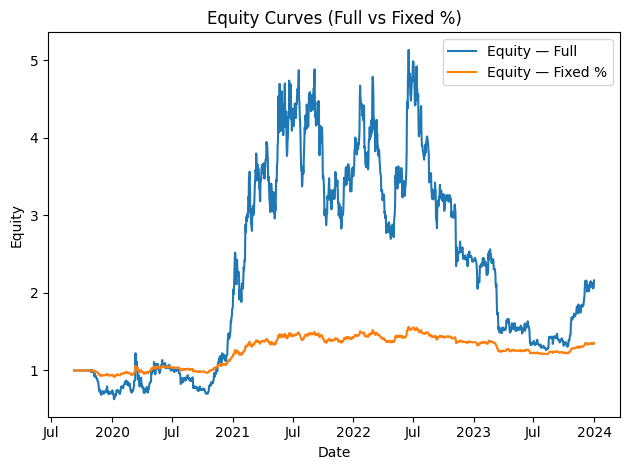

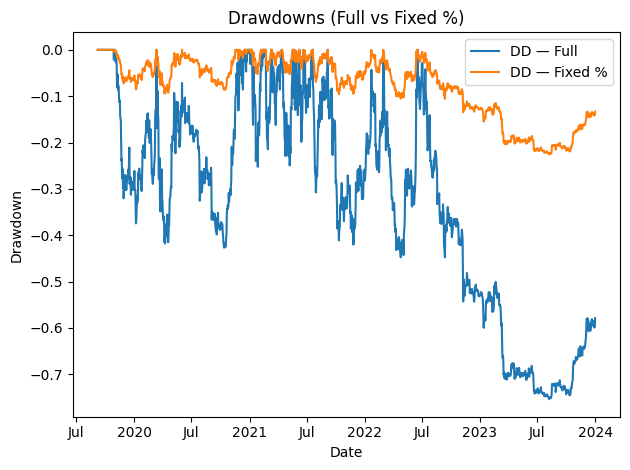

      Mode      CAGR   Vol_Ann    Sharpe     MaxDD  EquityEnd  Ndays
0     Full  0.130998  0.550718  0.494442 -0.753898   2.160538   1577
1  Fixed %  0.049608  0.110144  0.494442 -0.225699   1.353899   1577


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ghép kết quả vào một DataFrame thời gian
res_df = pd.DataFrame({
    "timestamp": strategy.df["timestamp"],
    "equity_full": res_full.equity.values,
    "equity_fixed": res_fp.equity.values,
})
res_df["dd_full"]  = (res_df["equity_full"] / res_df["equity_full"].cummax()) - 1.0
res_df["dd_fixed"] = (res_df["equity_fixed"] / res_df["equity_fixed"].cummax()) - 1.0

# 1) Equity curves
plt.figure()
plt.plot(res_df["timestamp"], res_df["equity_full"], label="Equity — Full")
plt.plot(res_df["timestamp"], res_df["equity_fixed"], label="Equity — Fixed %")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("Equity Curves (Full vs Fixed %)")
plt.xlabel("Date"); plt.ylabel("Equity"); plt.legend(); plt.tight_layout(); plt.show()

# 2) Drawdowns
plt.figure()
plt.plot(res_df["timestamp"], res_df["dd_full"], label="DD — Full")
plt.plot(res_df["timestamp"], res_df["dd_fixed"], label="DD — Fixed %")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("Drawdowns (Full vs Fixed %)")
plt.xlabel("Date"); plt.ylabel("Drawdown"); plt.legend(); plt.tight_layout(); plt.show()

# 3) Summary table
import numpy as np
summary_df = pd.DataFrame([
    {"Mode":"Full",    **res_full.summary},
    {"Mode":"Fixed %", **res_fp.summary},
])

# Chuyển np.float64 -> float cho gọn
for c in summary_df.columns:
    summary_df[c] = summary_df[c].apply(lambda x: float(x) if isinstance(x, (np.floating,)) else x)

print(summary_df)


### Cell 4 — Xuất kết quả (CSV) để review/chia sẻ

- **Mục tiêu:** Lưu lại các artefacts backtest để kiểm tra và đính kèm báo cáo.
- **File xuất:**
  - `trades_full.csv` / `trades_fixedpct.csv`: nhật ký giao dịch (timestamp, action, price, size/weight, equity_after).
  - `equity_curves.csv`: đường vốn của **Full** và **Fixed %** theo thời gian.
- **Lợi ích:** Dễ audit giao dịch, vẽ lại biểu đồ ngoài notebook, và tái lập kết quả.


In [8]:
# Export kết quả để gửi/đính kèm
res_full.trades.to_csv("trades_full.csv", index=False)
res_fp.trades.to_csv("trades_fixedpct.csv", index=False)

out_equity = pd.DataFrame({
    "timestamp": strategy.df["timestamp"],
    "equity_full": res_full.equity.values,
    "equity_fixed": res_fp.equity.values,
})
out_equity.to_csv("equity_curves.csv", index=False)

print("Saved: trades_full.csv, trades_fixedpct.csv, equity_curves.csv")


Saved: trades_full.csv, trades_fixedpct.csv, equity_curves.csv
